project title:- Credit Card Default Prediction (Classification)

In [1]:
# import libries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

head()- to show first 5 rows

In [2]:
# load dataset
df = pd.read_csv("UCI_Credit_Card.csv")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


shape - shows how many rows and columns are in the dataset

info()-shows data types and missing values in each column

describe()- shows basic statistics like min,max and count





In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


isnull() - checks for missing values in the dataset

sum() - counts the total number of missing values in each column.



In [4]:
#Check Missing Values
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


fillna()- fills missing values in the dataset

df.mean()-calculates the average values of each column

inplace=true- updates the original dataset directly

In [5]:
df.fillna(df.mean(), inplace=True)

sns.countplot() - creates a bar chart showing the count of each category.

x="default.payment.next.month"- the column whose values we want to count.

data=df - tells Seaborn to use the df dataset.

plt.show() - displays the graph.

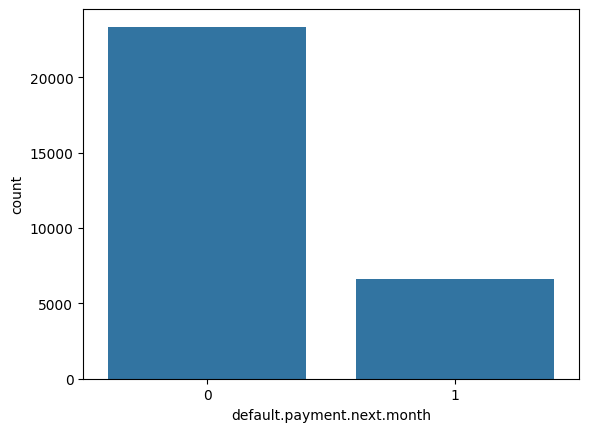

In [7]:
sns.countplot(x="default.payment.next.month", data=df)
plt.show()

drop() - removes a column from the dataset

"default.payment.next.month" - this is the target column we want to predict.

axis=1 - means column

axis=0 - means row.

In [9]:
# feature selection
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

Training data - used to train the model

Testing data - used to evaluate the model performance

X - Input features (independent variables)

y - Target variable (output)

X_train - Training input features

X_test - Testing input features

y_train -	Training target values

y_test -Testing target values

In [11]:
# train the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

StandardScaler() is used to normalize features by converting them to mean 0 and standard deviation 1.

scaler.fit_transform(X_train) - Calculates scaling values from training data and transforms it.

scaler.transform(X_test) - Applies the same scaling to test data without recalculating.

fit() - Learns the mean and standard deviation from the training data.

transform() - Uses those values to scale the data.

In [13]:
# normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

It is a classification algorithm used to predict categorical outcomes (like 0 or 1)

LogisticRegression() - Creates a logistic regression model.

lr.fit(X_train, y_train) - Trains the model using training data.

lr.predict(X_test) - Predicts the output for the test data.



In [14]:
# logistic model
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

accuracy_score() → Calculates how many predictions are correct.

confusion_matrix() → Shows correct and incorrect predictions in a table.

classification_report() → Displays precision, recall, f1-score, and accuracy of the model.

In [16]:
# evolution
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8098333333333333
[[4550  137]
 [1004  309]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



RandomForestClassifier - A machine learning algorithm that uses many decision trees to make better classification predictions


In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8131666666666667
[[4411  276]
 [ 845  468]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.36      0.46      1313

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



XGBClassifier - A machine learning algorithm that uses boosting to combine many trees and improve prediction accuracy.

In [19]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(confusion_matrix(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8158333333333333
[[4420  267]
 [ 838  475]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.36      0.46      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



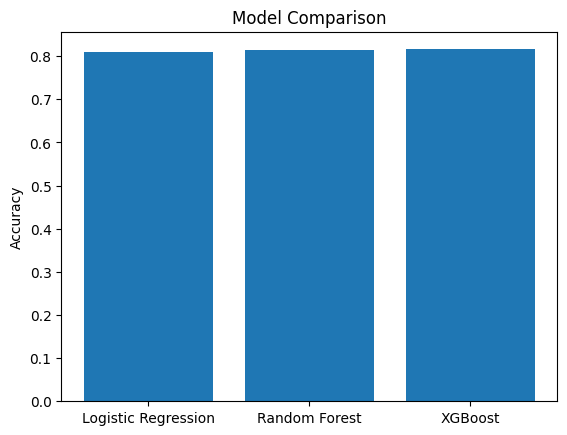

In [21]:
# compare the models
models = ['Logistic Regression','Random Forest','XGBoost']

accuracy = [
accuracy_score(y_test,y_pred_lr),
accuracy_score(y_test,y_pred_rf),
accuracy_score(y_test,y_pred_xgb)
]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

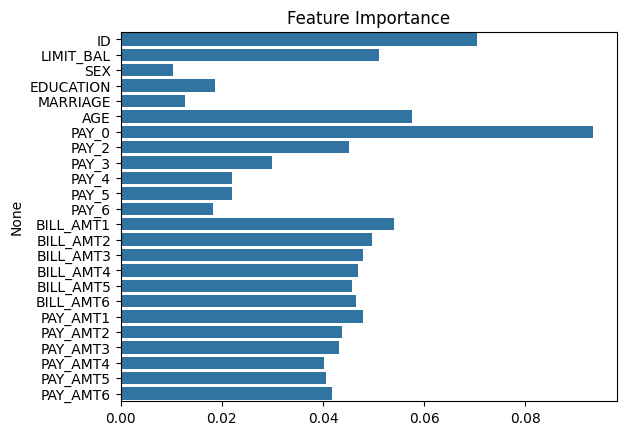

In [23]:
importances = rf.feature_importances_

features = df.drop("default.payment.next.month", axis=1).columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

In [26]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

In [29]:
import joblib
joblib.dump(pipeline, 'model_pipeline.pkl')
print("Model Pipeline saved successfully.")

Model Pipeline saved successfully.
